<a href="https://colab.research.google.com/github/thaygorh/Analise-de-Dados-e-Boas-Praticas/blob/main/mvp-analise-dados-e-boas-praticas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MVP Análise de Dados e Boas Práticas

**Autor:** Thaygor Henrique Gonçalves

**Matrícula:** 4052025000871

**Dataset:** [Predictive Maintenance Dataset (AI4I 2020)](https://www.kaggle.com/datasets/stephanmatzka/predictive-maintenance-dataset-ai4i-2020)


---

## 1. Definição do Problema

Este trabalho utiliza um dataset de manutenção de máquinas, contendo variáveis operacionais como temperatura, velocidade, torque e desgaste da ferramenta.

O objetivo da análise é identificar quais fatores estão relacionados à ocorrência de falhas e aos diferentes tipos de falha, representados pela variável "machine failure" e pelos indicadores específicos de cada falha.

A abordagem será baseada em análise exploratória de dados (EDA) e técnicas de pré-processamento, buscando entender o comportamento das variáveis, identificar padrões relevantes e avaliar a qualidade dos dados.

Com isso, espera-se não apenas extrair insights sobre as condições associadas às falhas, mas também preparar a base para possíveis aplicações futuras em modelos de machine learning.

### 1.1 Tipo de Problema

Este é um problema de classificação supervisionada. A variável alvo principal é "machine failure", que indica a ocorrência (1) ou não (0) de falha na máquina.

Além disso, o dataset contém variáveis adicionais que indicam tipos específicos de falha (TWF, HDF, PWF, OSF e RNF), permitindo uma análise mais detalhada das condições associadas à ocorrência de falhas.

A partir de variáveis operacionais como temperatura, velocidade de rotação, torque e desgaste da ferramenta, o objetivo é identificar padrões relacionados à ocorrência de falhas da máquina e compreender como esses fatores se relacionam com diferentes tipos de falha.

---

## 2. Hipóteses e Perguntas de Análise

Com base nas características do dataset, foram definidas hipóteses que buscam identificar possíveis relações entre as variáveis operacionais e a ocorrência de falhas nas máquinas.

### 2.1 Hipóteses

- H1: O aumento do desgaste da ferramenta (tool wear) está associado a uma maior probabilidade de ocorrência de falhas, podendo também influenciar outros tipos de falha.

- H2: A diferença entre a temperatura do processo e a temperatura do ar pode estar relacionada ao surgimento de falhas, indicando possíveis condições operacionais críticas.

- H3: Valores extremos de torque e velocidade de rotação tendem a estar associados à ocorrência de falhas, refletindo possíveis sobrecargas ou condições anormais de operação.

- H4: O tipo de produto (L, M, H), relacionado à qualidade e exigência operacional, pode influenciar tanto a ocorrência de falhas quanto a distribuição dos tipos de falha.

### 2.2 Perguntas de análise

Além das hipóteses, a análise será guiada pelas seguintes perguntas:

- Qual tipo de falha ocorre com maior frequência?
- Existe diferença no comportamento das variáveis entre situações com e sem falha?
- Há correlação relevante entre as variáveis do dataset?
- Quais variáveis apresentam maior potencial como indicadoras de falha?
- Existem padrões que diferenciam os tipos de falha?

Essas hipóteses e perguntas orientam a análise exploratória, permitindo uma investigação direcionada e fundamentada dos dados.

---

## 3. Importação e Carga de Dados

Nesta etapa, são importadas as bibliotecas necessárias para análise, visualização e pré-processamento dos dados. Também é realizada a configuração do ambiente e o carregamento do dataset a partir da URL do repositório no GitHub.

### 3.1 Importação das Bibliotecas

In [233]:
# Configuração para não exibir warnings
import warnings
warnings.filterwarnings('ignore')

# Manipulação de dados
import pandas as pd
import numpy as np

# Visualização de dados
import matplotlib.pyplot as plt
import seaborn as sns

# Pré-processamento
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# Configuração do estilo dos gráficos
sns.set(style='whitegrid')

### 3.2 Carga dos Dados

In [234]:
# carregamento do dataset (URL do dataset no GitHub)
url = "https://raw.githubusercontent.com/thaygorh/Analise-de-Dados-e-Boas-Praticas/refs/heads/main/Predictive%20Maintenance%20Dataset%20AI4I%202020.csv"

df = pd.read_csv(url)

In [235]:
# Visualizar as primeiras linhas do dataset original
df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


## 4. Estrutura e Qualidade dos Dados

Nesta etapa, é realizada uma análise inicial da estrutura do dataset, incluindo a quantidade de instâncias e variáveis, tipos de dados e verificação de possíveis inconsistências.

Também é apresentado um resumo estatístico das variáveis, permitindo uma compreensão geral dos dados antes das análises mais detalhadas.

### 4.1 Estrutura dos Dados

O dataset possui 10.000 instâncias e 14 variáveis.

Com base na inspeção dos tipos de dados:

- 3 variáveis são do tipo float64;
- 9 variáveis são do tipo int64;
- 2 variáveis são do tipo object.

Todas as colunas possuem 10.000 valores não nulos, conforme verificado na contagem de valores por variável.

A visualização das primeiras linhas permite compreender melhor a organização e a estrutura dos dados.

In [236]:
# quantidade total de instâncias (linhas)
print(f"Total de instâncias: {len(df)}")

# quantidade total de variáveis (colunas)
print(f"Total de variáveis: {df.shape[1]}")

print()

# tipos de dados
df.info()

print()

# visualização inicial
df.head()

Total de instâncias: 10000
Total de variáveis: 14

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      1

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


### 4.2 Resumo Estatístico dos Dados
Para complementar a análise inicial, utiliza-se a função `describe()` para obter um resumo estatístico das variáveis numéricas do dataset.

Essa etapa permite identificar padrões gerais, dispersão dos dados e possíveis valores fora do comportamento esperado.

In [237]:
df.describe()

,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900,0.004600,0.011500,0.009500,0.009800,0.00190
std,2886.89568,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981,0.067671,0.106625,0.097009,0.098514,0.04355
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,5000.50000,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,7500.25000,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000


## 5. Preparação Inicial e Padronização dos Dados

O dataset foi selecionado na plataforma Kaggle por representar um cenário de manutenção preditiva em máquinas industriais, com base em um processo de usinagem.

A base contém 10.000 registros e 14 variáveis, incluindo atributos operacionais e indicadores de falha. As variáveis operacionais descrevem condições de funcionamento da máquina, como temperatura, velocidade de rotação, torque e desgaste da ferramenta.

Além disso, o dataset inclui variáveis que representam modos específicos de falha (TWF, HDF, PWF, OSF e RNF), enquanto a variável `Machine failure` indica a ocorrência geral de falha.

Antes de iniciar a análise exploratória, foi criada uma versão do dataset contendo apenas as variáveis relevantes para a análise. Colunas sem relevância analítica direta, como identificadores únicos ou redundantes, foram removidas para facilitar a interpretação dos dados. O dataset original foi mantido preservado.

### 5.1 Remoção de Colunas Não Relevantes

Nesta etapa, são removidas as colunas `UDI` e `Product ID`.

A coluna `UDI` é apenas um identificador sequencial único, sem utilidade analítica para o problema. Já a coluna `Product ID` funciona como identificador do produto e não acrescenta valor relevante à análise, uma vez que o tipo do produto já está representado pela variável `Type`.

Com isso, permanece no dataset apenas o conjunto de variáveis com potencial analítico para as próximas etapas.

In [238]:
# remoção das colunas sem relevância analítica
df_analysis = df.drop(columns=['UDI', 'Product ID'])

df_analysis.head()

,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


### 5.2 Padronização dos Nomes das Variáveis

Após a remoção das colunas não relevantes, os nomes das variáveis são padronizados em português para tornar a análise mais clara ao longo do notebook.

Foram mantidas as unidades de medida originais e, no caso das falhas específicas, as siglas foram preservadas e acompanhadas de descrições mais interpretáveis. A base ajustada passa a ser referenciada como `df_analysis`.

In [239]:
colunas_renomeadas = {
    'Type': 'Tipo do produto',
    'Air temperature [K]': 'Temperatura do ar [K]',
    'Process temperature [K]': 'Temperatura do processo [K]',
    'Rotational speed [rpm]': 'Velocidade de rotação [rpm]',
    'Torque [Nm]': 'Torque [Nm]',
    'Tool wear [min]': 'Desgaste da ferramenta [min]',
    'Machine failure': 'Falha da máquina',
    'TWF': 'Falha TWF (Desgaste da ferramenta)',
'HDF': 'Falha HDF (Dissipação de calor)',
'PWF': 'Falha PWF (Potência)',
'OSF': 'Falha OSF (Sobrecarga)',
'RNF': 'Falha RNF (Aleatória)'
}

df_analysis = df_analysis.rename(columns=colunas_renomeadas)

df_analysis.head()

,Tipo do produto,Temperatura do ar [K],Temperatura do processo [K],Velocidade de rotação [rpm],Torque [Nm],Desgaste da ferramenta [min],Falha da máquina,Falha TWF (Desgaste da ferramenta),Falha HDF (Dissipação de calor),Falha PWF (Potência),Falha OSF (Sobrecarga),Falha RNF (Aleatória)
0,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


### 5.3 Atributos do Dataset

Após os ajustes realizados, o dataset df_analysis contém 10.000 registros e 12 variáveis, descritas a seguir:

- Tipo do produto (L = baixa, M = média, H = alta qualidade)

- Temperatura do ar [K] (temperatura do ar em Kelvin)

- Temperatura do processo [K] (temperatura do processo em Kelvin)

- Velocidade de rotação [rpm] (velocidade de rotação em rotações por minuto)

- Torque [Nm] (torque aplicado em Newton-metro)

- Desgaste da ferramenta [min] (tempo de uso da ferramenta em minutos)

- Falha da máquina (indica ocorrência de falha geral: 0 = não, 1 = sim)

- Falha TWF (desgaste da ferramenta)

- Falha HDF (dissipação de calor no processo)

- Falha PWF (relacionada à potência do processo)

- Falha OSF (sobrecarga operacional)

- Falha RNF (falha aleatória)

---

## 6. Análise Exploratória dos Dados (EDA)

Nesta etapa, é realizada a análise exploratória dos dados com o objetivo de identificar padrões, comportamentos e possíveis relações entre as variáveis do dataset.

A análise será conduzida por meio de visualizações e estatísticas descritivas, buscando compreender a distribuição dos dados, diferenças entre situações com e sem falha e possíveis indicadores relevantes para a ocorrência de falhas.

### 6.1 Estatísticas Descritivas

Antes da análise gráfica, são avaliadas as estatísticas descritivas das variáveis numéricas, como média, mediana, desvio padrão e quartis.

Essa etapa permite compreender a tendência central e a dispersão dos dados, servindo como base para interpretação das distribuições apresentadas na sequência.

#### 6.1.1 Média das variáveis

A média foi calculada para as variáveis numéricas do dataset.
Para as variáveis contínuas, a média representa o valor típico observado nos dados.
Já para as variáveis binárias (indicadores de falha), a média representa a proporção de ocorrência de cada tipo de falha no dataset, permitindo interpretar a frequência relativa desses eventos.

In [240]:
# médias das variáveis contínuas
colunas_continuas = [
    'Temperatura do ar [K]',
    'Temperatura do processo [K]',
    'Velocidade de rotação [rpm]',
    'Torque [Nm]',
    'Desgaste da ferramenta [min]'
]

df_analysis[colunas_continuas].mean()

,0
Temperatura do ar [K],300.00493
Temperatura do processo [K],310.00556
Velocidade de rotação [rpm],1538.77610
Torque [Nm],39.98691
Desgaste da ferramenta [min],107.95100


In [241]:
# médias das variáveis binárias (taxa de falha)
colunas_binarias = [
    'Falha da máquina',
    'Falha TWF (Desgaste da ferramenta)',
    'Falha HDF (Dissipação de calor)',
    'Falha PWF (Potência)',
    'Falha OSF (Sobrecarga)',
    'Falha RNF (Aleatória)'
]

df_analysis[colunas_binarias].mean()

,0
Falha da máquina,0.0339
Falha TWF (Desgaste da ferramenta),0.0046
Falha HDF (Dissipação de calor),0.0115
Falha PWF (Potência),0.0095
Falha OSF (Sobrecarga),0.0098
Falha RNF (Aleatória),0.0019


### Interpretação das variáveis binárias na média

As variáveis binárias (0 e 1), que indicam ocorrência de falhas, possuem uma interpretação específica na análise estatística.

Onde:
- 0 representa ausência de falha
- 1 representa ocorrência de falha

Dessa forma, a média dessas variáveis não deve ser interpretada como um valor médio convencional, mas sim como a proporção de ocorrências em relação ao total de registros.

Ou seja, a média pode ser interpretada como:
- Taxa de ocorrência da falha
- Probabilidade empírica da falha no dataset

No caso deste dataset, isso significa que:

- Falha da máquina = 3,39%
- Falha TWF (Desgaste da ferramenta) = 0,46%
- Falha HDF (Dissipação de calor) = 1,15%
- Falha PWF (Potência) = 0,95%
- Falha OSF (Sobrecarga) = 0,98%
- Falha RNF (Aleatória) = 0,19%

Essa interpretação é importante para compreender a frequência dos eventos e auxilia na análise do comportamento das falhas no conjunto de dados.

### 6.1.2 Mediana das variáveis

A mediana representa o valor central dos dados, sendo menos sensível a valores extremos (outliers).

Nesta etapa, a mediana será analisada apenas para as variáveis contínuas, pois para variáveis binárias essa medida tende a não trazer informações relevantes, assumindo frequentemente valor igual a 0 devido à baixa ocorrência de falhas no dataset.

In [242]:
# mediana das variáveis contínuas
colunas_continuas = [
    'Temperatura do ar [K]',
    'Temperatura do processo [K]',
    'Velocidade de rotação [rpm]',
    'Torque [Nm]',
    'Desgaste da ferramenta [min]'
]

df_analysis[colunas_continuas].median()

,0
Temperatura do ar [K],300.1
Temperatura do processo [K],310.1
Velocidade de rotação [rpm],1503.0
Torque [Nm],40.1
Desgaste da ferramenta [min],108.0


### 6.1.3 Moda das variáveis

A moda representa o valor mais frequente em cada variável do dataset, indicando o valor mais recorrente observado nos dados.

Nesta etapa, a moda será analisada apenas para as variáveis contínuas, pois para variáveis binárias essa medida tende a não trazer informações relevantes, já que o valor mais frequente será, na maioria dos casos, 0, indicando ausência de falha na maior parte dos registros.

In [243]:
# moda das variáveis contínuas
colunas_continuas = [
    'Temperatura do ar [K]',
    'Temperatura do processo [K]',
    'Velocidade de rotação [rpm]',
    'Torque [Nm]',
    'Desgaste da ferramenta [min]'
]

df_analysis[colunas_continuas].mode().iloc[0]

,0
Temperatura do ar [K],300.7
Temperatura do processo [K],310.6
Velocidade de rotação [rpm],1452.0
Torque [Nm],40.2
Desgaste da ferramenta [min],0.0


### 6.1.4 Desvio padrão

O desvio padrão mede a dispersão dos dados em relação à média, indicando o quanto os valores variam dentro de cada variável.

Nesta etapa, o desvio padrão será analisado apenas para as variáveis contínuas, pois para variáveis binárias essa medida tende a não agregar informações relevantes no contexto da análise.

In [244]:
# desvio padrão das variáveis contínuas
colunas_continuas = [
    'Temperatura do ar [K]',
    'Temperatura do processo [K]',
    'Velocidade de rotação [rpm]',
    'Torque [Nm]',
    'Desgaste da ferramenta [min]'
]

df_analysis[colunas_continuas].std()

,0
Temperatura do ar [K],2.000259
Temperatura do processo [K],1.483734
Velocidade de rotação [rpm],179.284096
Torque [Nm],9.968934
Desgaste da ferramenta [min],63.654147


### Interpretação do desvio padrão

Observa-se que a variável **Velocidade de rotação [rpm]** apresenta o maior desvio padrão, indicando maior variabilidade nos valores de rotação ao longo do dataset.

A variável **Desgaste da ferramenta [min]** também apresenta alta dispersão, o que sugere diferentes níveis de desgaste das ferramentas ao longo das observações.

Por outro lado, as variáveis **Temperatura do ar [K]** e **Temperatura do processo [K]** apresentam baixo desvio padrão, indicando que seus valores são mais estáveis e concentrados em torno da média.

Já a variável **Torque [Nm]** apresenta uma dispersão intermediária, indicando variação moderada ao longo do dataset.

### 6.1 Distribuição das Falhas

Inicialmente, é analisada a distribuição da variável "Falha da máquina", com o objetivo de entender a frequência de ocorrência de falhas no dataset.

Além disso, são analisados os diferentes tipos de falha, permitindo uma visão mais detalhada dos eventos registrados.

O gráfico de barras foi utilizado para analisar a frequência de ocorrência de cada tipo de falha no conjunto de dados.

Observa-se que a Falha HDF (dissipação de calor) é o tipo de falha mais frequente, seguida pela Falha OSF (sobrecarga) e pela Falha PWF (potência).

As Falhas TWF (desgaste da ferramenta) e RNF (aleatória) apresentam menor incidência quando comparadas às demais, indicando que esses eventos ocorrem com menor frequência.

Essa análise permite identificar quais falhas são mais recorrentes no dataset, contribuindo para direcionar etapas de modelagem e possíveis ações de monitoramento.

In [245]:
# distribuição da variável alvo
df_analysis['Falha da máquina'].value_counts()

,count
Falha da máquina,
0,9661
1,339


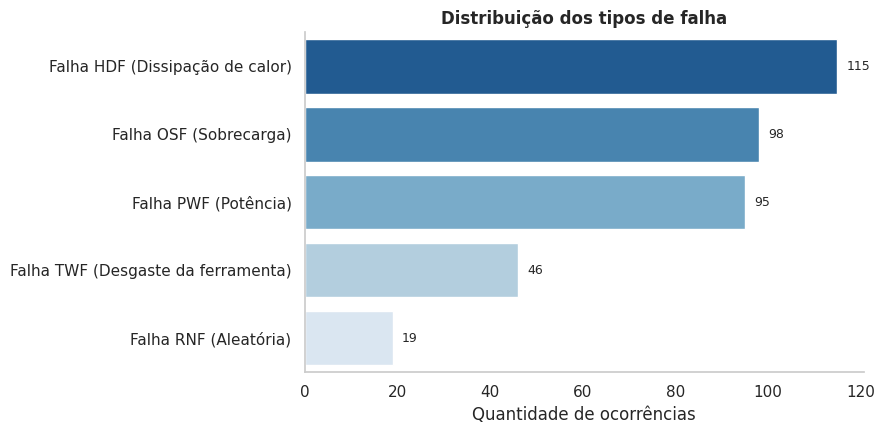

In [246]:
# colunas dos tipos de falha
colunas_falhas = [
    'Falha TWF (Desgaste da ferramenta)',
    'Falha HDF (Dissipação de calor)',
    'Falha PWF (Potência)',
    'Falha OSF (Sobrecarga)',
    'Falha RNF (Aleatória)'
]

# contagem total de ocorrências por tipo de falha
counts = df_analysis[colunas_falhas].sum().sort_values(ascending=False)

plt.figure(figsize=(9, 4.5))

ax = sns.barplot(
    x=counts.values,
    y=counts.index,
    palette='Blues_r'
)

# adicionar valores nas barras
for i, v in enumerate(counts.values):
    ax.text(v + 2, i, str(int(v)), va='center', fontsize=9)

# ajustes visuais
plt.title('Distribuição dos tipos de falha', fontsize=12, weight='bold')
plt.xlabel('Quantidade de ocorrências')
plt.ylabel('')

sns.despine()
plt.grid(False)
plt.tight_layout()
plt.show()

### Distribuição das variáveis contínuas em relação à falha (Histograma)

Os histogramas serão utilizados para analisar a distribuição das variáveis contínuas do dataset.

Além disso, será feita uma comparação entre os registros com falha (Machine failure = 1) e sem falha (Machine failure = 0), com o objetivo de identificar possíveis padrões ou comportamentos distintos associados à ocorrência de falhas.

Essa análise permite verificar se determinados intervalos de valores das variáveis estão mais associados à ocorrência de falhas, contribuindo para o entendimento do problema.

KeyError: 'Machine failure'

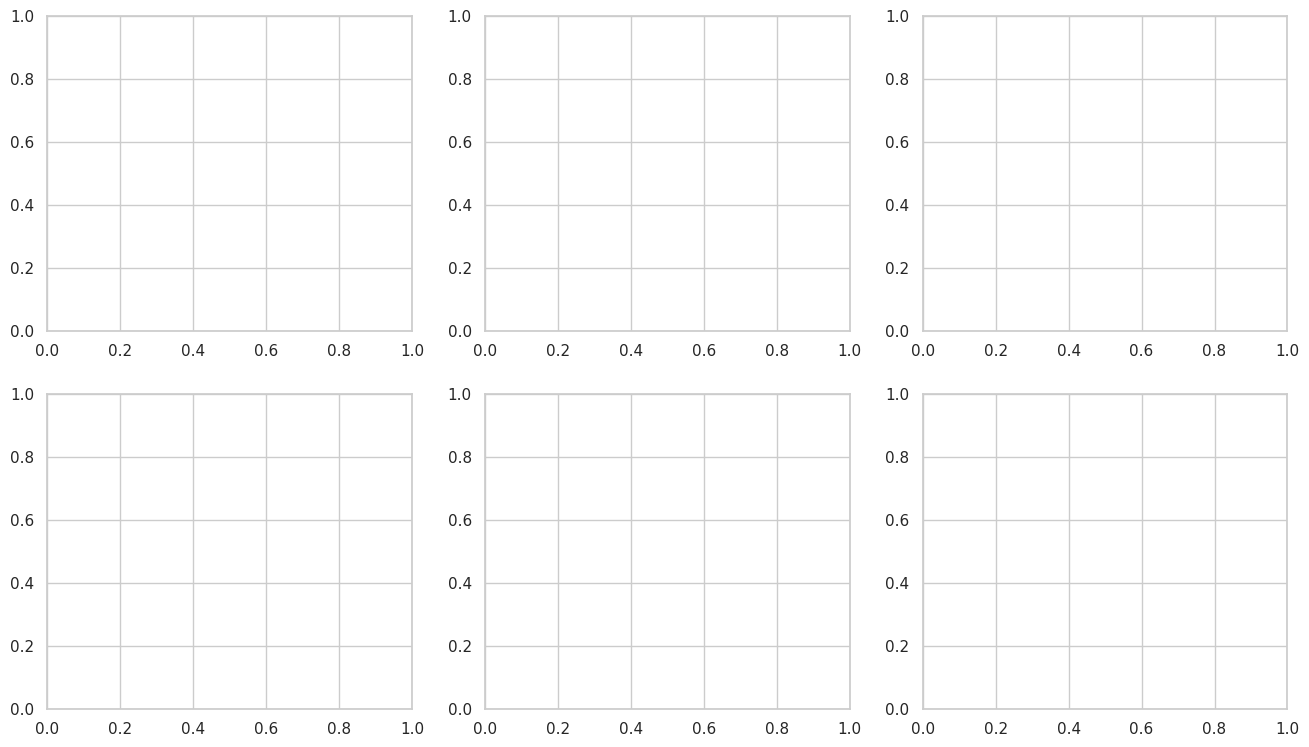

In [247]:
import matplotlib.pyplot as plt

variaveis = [
    'Air temperature [K]',
    'Process temperature [K]',
    'Rotational speed [rpm]',
    'Torque [Nm]',
    'Tool wear [min]'
]

fig, axes = plt.subplots(2, 3, figsize=(16,9))
axes = axes.flatten()

for i, var in enumerate(variaveis):
    ax = axes[i]

    # sem falha (azul)
    df_analysis[df_analysis['Machine failure'] == 0][var].hist(
        bins=20, alpha=0.5, color='#4C72B0', ax=ax
    )

    # com falha (laranja)
    df_analysis[df_analysis['Machine failure'] == 1][var].hist(
        bins=20, alpha=0.8, color='#DD8452', ax=ax
    )

    ax.set_title(var, fontsize=11)

    # 🔥 agora mostramos o eixo Y corretamente
    ax.set_ylabel('Frequência', fontsize=9)

    # remover label do eixo X (menos poluição)
    ax.set_xlabel('')

    # grid mais fino
    ax.grid(True, linewidth=0.3, alpha=0.5)

    # remover bordas
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# remover gráfico vazio
fig.delaxes(axes[5])

fig.suptitle(
    'Distribuição das variáveis contínuas com destaque para ocorrências de falha',
    fontsize=14,
    y=0.98
)

plt.subplots_adjust(hspace=0.35, wspace=0.25)

plt.show()

### Principais padrões observados nos histogramas

Os histogramas mostram como os registros com falha (**Machine failure = 1**) se distribuem em relação às variáveis contínuas.

- **Air temperature [K]** e **Process temperature [K]**: a distribuição das falhas acompanha a distribuição geral, sem um padrão visual tão evidente.
- **Rotational speed [rpm]**: os registros com falha aparecem com maior concentração em faixas mais baixas de rotação.
- **Torque [Nm]**: as falhas se concentram mais em faixas elevadas de torque.
- **Tool wear [min]**: os registros com falha aparecem com maior concentração em valores mais altos de desgaste.

Esses gráficos não indicam, por si só, qual variável é mais importante, mas ajudam a identificar em quais variáveis o comportamento das falhas se destaca de forma mais clara.

### Análise comparativa das variáveis por ocorrência de falha (Boxplot)

Os boxplots são utilizados para comparar a distribuição das variáveis contínuas entre os registros com e sem falha (Machine failure).

Essa visualização permite identificar diferenças de comportamento entre os grupos, destacando variações na mediana, dispersão e presença de outliers.

Diferentemente dos histogramas, os boxplots facilitam a comparação direta entre os grupos, tornando mais evidente onde os valores associados à falha se diferenciam do comportamento geral.

In [ ]:
variaveis = [
    'Air temperature [K]',
    'Process temperature [K]',
    'Rotational speed [rpm]',
    'Torque [Nm]',
    'Tool wear [min]'
]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, var in enumerate(variaveis):
    ax = axes[i]

    sns.boxplot(
        data=df_analysis,
        x='Machine failure',
        y=var,
        ax=ax,
        palette=['#4C72B0', '#DD8452'],
        showfliers=True
    )

    ax.set_title(var, fontsize=11)
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.set_xticklabels(['Sem falha', 'Com falha'])

    # 🔥 escala fixa para temperaturas
    if var in ['Air temperature [K]', 'Process temperature [K]']:
        ax.set_ylim(295, 315)
        ax.set_yticks(range(295, 316, 5))  # ticks organizados

    # grid leve
    ax.grid(True, linewidth=0.3, alpha=0.4)

    # remover bordas desnecessárias
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# remover último subplot vazio
fig.delaxes(axes[5])

fig.suptitle(
    'Comparação das variáveis contínuas por ocorrência de falha',
    fontsize=14,
    y=0.98
)

plt.subplots_adjust(hspace=0.35, wspace=0.25)

plt.show()

### Principais padrões observados nos boxplots

Os boxplots mostram como os registros com falha (**Machine failure = 1**) se distribuem em relação às variáveis contínuas, permitindo comparar mediana, dispersão e presença de outliers entre os grupos.

- **Air temperature [K] e Process temperature [K]**: apresentam distribuições muito semelhantes entre os grupos, sem diferenças relevantes na mediana ou dispersão.
- **Rotational speed [rpm]**: os registros com falha apresentam mediana inferior e maior presença de valores extremos, indicando associação com faixas mais baixas de rotação e maior variabilidade.
- **Torque [Nm]**: o grupo com falha apresenta mediana mais alta e maior variabilidade, com presença de valores extremos, indicando concentração em faixas mais elevadas de torque.
- **Tool wear [min]**: os registros com falha apresentam mediana mais elevada e maior dispersão, além de valores extremos mais frequentes, indicando forte relação com o desgaste da ferramenta.

A presença de outliers em algumas variáveis indica a ocorrência de valores extremos nos dados. No entanto, não é possível estabelecer uma relação direta entre esses valores e a ocorrência de falhas.

### Relação linear entre as variáveis (Matriz de Correlação)

A matriz de correlação será utilizada para analisar o grau de relação linear entre as variáveis numéricas do dataset, permitindo identificar possíveis padrões entre elas.

Os valores de correlação variam de -1 a 1, onde valores próximos de 1 indicam forte correlação positiva, valores próximos de -1 indicam correlação negativa (inversamente proporcional) e valores próximos de 0 indicam ausência de correlação linear.

Por considerar apenas relações lineares, essa análise pode não capturar completamente a influência das variáveis na ocorrência de falhas, especialmente em cenários com dados desbalanceados.

In [ ]:
# selecionar apenas colunas numéricas
corr = df_analysis.select_dtypes(include='number').corr()

plt.figure(figsize=(10, 8))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Matriz de Correlação das Variáveis Numéricas")
plt.show()

### Principais padrões observados na matriz de correlação

A matriz de correlação permite observar a intensidade da relação linear entre as variáveis numéricas do dataset.

Observa-se que:

- **Air temperature [K] e Process temperature [K]** apresentam alta correlação positiva, indicando comportamento muito semelhante entre essas variáveis.
- **Rotational speed [rpm] e Torque [Nm]** apresentam forte correlação negativa, evidenciando uma relação inversa entre rotação e torque.

- As variáveis contínuas (temperaturas, rotação, torque e desgaste) apresentam baixa correlação linear com a variável **Machine failure**. No entanto, esse resultado pode ser influenciado pelo desbalanceamento da variável alvo, uma vez que a maior parte dos registros corresponde a condições sem falha, o que pode reduzir a capacidade da correlação linear de capturar padrões relevantes.

- As variáveis **TWF, HDF, PWF e OSF** apresentam correlação linear moderada com **Machine failure** (entre ~0.36 e ~0.58), indicando relação direta com os tipos específicos de falha.

- A variável **RNF** não apresenta correlação relevante com a falha.

Esses resultados reforçam que a análise de correlação linear, isoladamente, pode não ser suficiente para explicar a ocorrência de falhas, sendo necessária a utilização de abordagens mais robustas nas etapas seguintes.

### Relação entre variáveis contínuas e ocorrência de falha (Pairplot)

O pairplot será utilizado para visualizar, de forma conjunta, a distribuição das variáveis contínuas e a relação entre seus pares.

Ao destacar os registros com e sem falha por cor, esse gráfico permite observar se existem padrões de separação, agrupamentos ou combinações de variáveis em que a ocorrência de falhas se torna mais evidente.

Por reunir várias comparações em uma única visualização, o pairplot pode complementar os histogramas, boxplots e a matriz de correlação, especialmente na identificação de padrões visuais não lineares.

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# criar coluna com o tipo de falha
def map_failure(row):
    if row['TWF'] == 1:
        return 'TWF'
    elif row['HDF'] == 1:
        return 'HDF'
    elif row['PWF'] == 1:
        return 'PWF'
    elif row['OSF'] == 1:
        return 'OSF'
    elif row['RNF'] == 1:
        return 'RNF'
    else:
        return 'No Failure'

df_analysis['Failure Type'] = df_analysis.apply(map_failure, axis=1)

sns.set(style="white", context="notebook")

# IMPORTANTE: incluir todas as classes existentes
palette = {
    'No Failure': '#D9D9D9',
    'PWF': '#F28E2B',
    'TWF': '#59A14F',
    'OSF': '#E15759',
    'RNF': '#B07AA1',
    'HDF': '#4E79A7'
}

g = sns.pairplot(
    df_analysis[
        [
            'Air temperature [K]',
            'Process temperature [K]',
            'Rotational speed [rpm]',
            'Torque [Nm]',
            'Tool wear [min]',
            'Failure Type'
        ]
    ],
    hue='Failure Type',
    palette=palette,
    diag_kind='kde',
    plot_kws={
        's': 25,
        'alpha': 0.75
    },
    diag_kws={
        'fill': False
    }
)

g.fig.suptitle(
    'Pairplot das variáveis por tipo de falha',
    y=1.02,
    fontsize=14
)

# mover legenda para fora
g._legend.set_bbox_to_anchor((1.25, 0.5))
g._legend.set_title('Tipo de falha')

novos_rotulos = [
    'Sem falha',
    'PWF - potência',
    'TWF - desgaste da ferramenta',
    'OSF - sobrecarga operacional',
    'RNF - falha aleatória',
    'HDF - térmica'
]

for texto, novo in zip(g._legend.texts, novos_rotulos):
    texto.set_text(novo)

g.fig.subplots_adjust(right=0.80)

plt.show()

### Análise do pairplot com foco nos tipos de falha

O pairplot foi utilizado para identificar a distribuição dos diferentes tipos de falha e sua relação com as variáveis operacionais do processo.

A classe **“Sem falha”** é predominante no conjunto de dados, o que já era esperado. Entre as ocorrências de falha, destaca-se maior concentração de registros associados ao tipo **PWF (falha relacionada à potência)**, indicando que este é o tipo mais recorrente no dataset.

Em termos de distribuição, as falhas não se apresentam de forma aleatória, sendo possível identificar regiões de maior concentração associadas a determinadas variáveis:

- As falhas do tipo **PWF** tendem a se concentrar em cenários de **alta rotação (Rotational speed)** combinada com **baixo torque (Torque)**, sugerindo uma relação com condições operacionais onde há maior demanda dinâmica do sistema.

- As falhas do tipo **OSF (sobrecarga operacional)** e **TWF (desgaste da ferramenta)** apresentam maior incidência em valores elevados de **Tool wear**, indicando que o desgaste acumulado pode ser um fator relevante para a ocorrência dessas falhas.

- Já as falhas do tipo **HDF (condições térmicas)** não demonstram separação clara em relação às variáveis de temperatura (Air e Process temperature), o que sugere que essas variáveis, isoladamente, não são suficientes para explicar esse tipo de ocorrência.

Além disso, a relação entre **Rotational speed** e **Torque** evidencia um comportamento inverso consistente, independentemente do tipo de falha, refletindo uma característica estrutural do sistema e não necessariamente um fator discriminante entre classes.

De forma geral, observa-se uma **alta sobreposição entre os diferentes tipos de falha**, indicando que não há separação linear evidente entre as classes. Esse comportamento sugere que a identificação dos tipos de falha pode depender da combinação de múltiplas variáveis, reforçando a necessidade de abordagens analíticas mais robustas, como modelos de machine learning, para melhor discriminação.

Assim, o gráfico permite concluir que:
- O tipo de falha mais recorrente é o **PWF**;
- Existem regiões específicas do espaço de variáveis onde as falhas tendem a se concentrar;
- A distinção entre tipos de falha não é trivial e exige análise multivariada.

### Distribuição dos tipos de falha

O gráfico de barras foi utilizado para analisar a frequência de ocorrência de cada tipo de falha no conjunto de dados.

Observa-se que a **HDF (falha térmica)** é o tipo de falha mais frequente, seguida por **PWF (falha relacionada à potência)** e **OSF (sobrecarga operacional)**.

As falhas **TWF (desgaste da ferramenta)** e **RNF (falha aleatória)** apresentam menor incidência quando comparadas às demais, indicando que esses eventos ocorrem com menor frequência.

Essa análise permite identificar quais falhas são mais recorrentes no dataset, contribuindo para direcionar etapas de modelagem e possíveis ações de monitoramento.

In [ ]:
# filtrar apenas os registros com falha
df_failures = df_analysis[df_analysis['Failure Type'] != 'No Failure'].copy()

# contagem ordenada
counts = df_failures['Failure Type'].value_counts()

plt.figure(figsize=(8,4))

ax = sns.barplot(
    x=counts.values,
    y=counts.index,
    palette="Blues_r"
)

# adicionar valores nas barras
for i, v in enumerate(counts.values):
    ax.text(v + 2, i, str(v), va='center', fontsize=9)

# ajustes visuais
plt.title("Distribuição dos tipos de falha", fontsize=12, weight='bold')
plt.xlabel("Quantidade de ocorrências")
plt.ylabel("")

sns.despine()
plt.grid(False)

plt.tight_layout()
plt.show()

### 6.1 Distribuição das Falhas

Inicialmente, é analisada a distribuição da variável "Falha da máquina", com o objetivo de entender a frequência de ocorrência de falhas no dataset.

Além disso, são analisados os diferentes tipos de falha, permitindo uma visão mais detalhada dos eventos registrados.

O gráfico de barras foi utilizado para analisar a frequência de ocorrência de cada tipo de falha no conjunto de dados.

Observa-se que a Falha HDF (dissipação de calor) é o tipo de falha mais frequente, seguida pela Falha OSF (sobrecarga) e pela Falha PWF (potência).

As Falhas TWF (desgaste da ferramenta) e RNF (aleatória) apresentam menor incidência quando comparadas às demais, indicando que esses eventos ocorrem com menor frequência.

Essa análise permite identificar quais falhas são mais recorrentes no dataset, contribuindo para direcionar etapas de modelagem e possíveis ações de monitoramento.

In [ ]:
# distribuição da variável alvo
df_analysis['Falha da máquina'].value_counts()

In [ ]:
# colunas dos tipos de falha
colunas_falhas = [
    'Falha TWF (Desgaste da ferramenta)',
    'Falha HDF (Dissipação de calor)',
    'Falha PWF (Potência)',
    'Falha OSF (Sobrecarga)',
    'Falha RNF (Aleatória)'
]

# contagem total de ocorrências por tipo de falha
counts = df_analysis[colunas_falhas].sum().sort_values(ascending=False)

plt.figure(figsize=(9, 4.5))

ax = sns.barplot(
    x=counts.values,
    y=counts.index,
    palette='Blues_r'
)

# adicionar valores nas barras
for i, v in enumerate(counts.values):
    ax.text(v + 2, i, str(int(v)), va='center', fontsize=9)

# ajustes visuais
plt.title('Distribuição dos tipos de falha', fontsize=12, weight='bold')
plt.xlabel('Quantidade de ocorrências')
plt.ylabel('')

sns.despine()
plt.grid(False)
plt.tight_layout()
plt.show()

### 6.2 Distribuição das Variáveis Numéricas

Nesta etapa, é analisada a distribuição das variáveis numéricas do dataset, com o objetivo de compreender o comportamento dos dados, sua dispersão e possíveis padrões.

A análise das distribuições permite identificar características como concentração de valores, assimetrias e presença de valores extremos, contribuindo para uma melhor compreensão do comportamento operacional das variáveis.

In [ ]:
for col in colunas_numericas:
    plt.figure(figsize=(6,4))
    sns.histplot(df_analysis[col], kde=True)
    plt.title(f'Distribuição de {col}')
    plt.show()